In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import json
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers, layers
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

In [2]:

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '0 '
import warnings
warnings.filterwarnings('ignore')

class DataGenerator(keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=32, img_size=(128, 128)):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.indices = np.arange(len(self.image_paths))

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_paths = [self.image_paths[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        batch_images = []
        for path in batch_paths:
            img = cv2.imread(str(path))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
                img = img.astype(np.float32) / 255.0
                batch_images.append(img)
            else:
                batch_images.append(np.zeros((*self.img_size, 3), dtype=np.float32))

        return np.array(batch_images), np.array(batch_labels)

loading dataset

In [3]:
component_folders = {
        i: i for i in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
        }

image_paths = []
labels = []
components = list(component_folders.values())

print(" Collecting image paths...")

for folder_name, component in component_folders.items():
  folder_path = Path("/content/drive/MyDrive/Datasci3proj/datasci3/Collated") / folder_name # <============================== change for pathing
  images = list(folder_path.glob('*.jpg')) + list(folder_path.glob('*.png')) + \
          list(folder_path.glob('*.jpeg')) + list(folder_path.glob('*.JPG'))

  print(f"   {folder_name}/ -> {component}: {len(images)} images")

  for img_path in images:
      image_paths.append(img_path)
      labels.append(components.index(component))

if len(image_paths) == 0:
  print(" ERROR: No images found! ")

   A/ -> A: 450 images
   B/ -> B: 450 images
   C/ -> C: 450 images
   D/ -> D: 450 images
   E/ -> E: 450 images
   F/ -> F: 450 images
   G/ -> G: 450 images
   H/ -> H: 450 images
   I/ -> I: 450 images
   J/ -> J: 450 images
   K/ -> K: 450 images
   L/ -> L: 450 images
   M/ -> M: 450 images
   N/ -> N: 450 images
   O/ -> O: 450 images
   P/ -> P: 450 images
   Q/ -> Q: 450 images
   R/ -> R: 450 images
   S/ -> S: 450 images
   T/ -> T: 450 images
   U/ -> U: 450 images
   V/ -> V: 450 images
   W/ -> W: 450 images
   X/ -> X: 450 images
   Y/ -> Y: 450 images
   Z/ -> Z: 450 images


spliting dataset

In [4]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
        image_paths, labels, test_size=0.2, random_state=42, stratify=labels
    )

print(f" Data split: {len(train_paths)} training, {len(val_paths)} validation")

 Data split: 9360 training, 2340 validation


model training

In [5]:
def train_model(x,name):

    batch_size = 32
    train_generator = DataGenerator(train_paths, train_labels, batch_size=batch_size)
    val_generator = DataGenerator(val_paths, val_labels, batch_size=batch_size)

    model = x


    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        train_generator,
        epochs=20,
        validation_data=val_generator,
        verbose=2
    )

    model.save(name + '.h5')
    print(f" Model saved as {name}")

    print(" Dataset info saved as 'batch1_dataset_info.json'")

    val_loss, val_accuracy = model.evaluate(val_generator)
    print(f" Final Validation Accuracy: {val_accuracy:.2%}")

Baseline model

In [7]:
model_baseline = keras.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(components), activation='softmax')
    ])

In [ ]:
train_model(model_baseline,'batch1_model_baseline')

Hypertuned model

In [ ]:
model_hypertuned = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(len(components), activation="softmax")
])

In [ ]:
name = 'fsl_abc_tiny'
train_model(model_hypertuned,name)

transfer learning

In [ ]:
from tensorflow.keras.applications import MobileNetV2

def create_mobilenet_model(input_shape=(128, 128, 3), num_classes=len(components)):
    base_model = MobileNetV2(input_shape=input_shape,
                             include_top=False,
                             weights='imagenet')

    base_model.trainable = True

    for layer in base_model.layers[:-10]: # use only the last 10 layers
        layer.trainable = False

    model_mobilenet = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model_mobilenet

model_mobilenet = create_mobilenet_model()

In [ ]:
name = 'mobilenet'
train_model(model_mobilenet, name)

Load Model

In [6]:
model_baseline = load_model('/content/batch1_model_baseline.h5')
model_hypertuned = load_model('/content/fsl_abc_tiny.h5')
model_mobilenet = load_model('/content/mobilenet.h5')

In [7]:
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,395,676 (28.21 MB)

 Trainable params: 7,395,674 (28.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [8]:
model_hypertuned.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,580 (2.03 MB)

 Trainable params: 531,354 (2.03 MB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 2 (12.00 B)

In [9]:
model_mobilenet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,308 (9.25 MB)

 Trainable params: 899,802 (3.43 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

 Optimizer params: 2 (12.00 B)

In [11]:
def visualize_model(model):
    component_names = components

    expected_img_size = model.input_shape[1:3]

    print(f"Loading and processing {len(val_paths)} validation images...")
    X_test = []
    valid_labels_clean = []

    for path, label in zip(val_paths, val_labels):
        img = cv2.imread(str(path))
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, expected_img_size) # Use the model's expected size
        img = img.astype(np.float32) / 255.0

        X_test.append(img)
        valid_labels_clean.append(label)

    X_test = np.array(X_test)
    y_test = np.array(valid_labels_clean)

    print("Loading model and predicting...")

    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # --- 6. Metrics ---
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\nResults:\nAccuracy: {acc:.4f}\nF1 Score: {f1:.4f}")

    # --- 7. CLASSIFICATION REPORT ---
    report = classification_report(
        y_test,
        y_pred,
        target_names=component_names,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose().round(2)

    report_df = report_df.rename(columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1-Score",
        "support": "Support"
    })

    report_df = report_df.drop(index=["accuracy"], errors="ignore")

    print("\n=== Classification Report ===")
    print(report_df)


    # --- 8. Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(16, 14))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(component_names))
    plt.xticks(tick_marks, component_names, rotation=90, fontsize=6)
    plt.yticks(tick_marks, component_names, fontsize=6)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

    # --- 9. ROC Curve ---
    y_test_bin = label_binarize(y_test, classes=list(range(len(component_names))))

    plt.figure(figsize=(10, 8))
    for i in range(min(5, len(component_names))):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
        plt.plot(fpr, tpr, label=f"{component_names[i]} (AUC = {auc(fpr, tpr):.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (Sample Classes)")
    plt.legend(loc="lower right")
    plt.show()

Loading and processing 2340 validation images...
Loading model and predicting...
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 230ms/step

Results:
Accuracy: 0.9786
F1 Score: 0.9787

=== Classification Report ===
              Precision  Recall  F1-Score  Support
A                  0.99    0.98      0.98     90.0
B                  0.96    1.00      0.98     90.0
C                  1.00    0.98      0.99     90.0
D                  0.99    1.00      0.99     90.0
E                  0.98    0.99      0.98     90.0
F                  0.97    0.98      0.97     90.0
G                  0.98    0.98      0.98     90.0
H                  0.96    0.99      0.97     90.0
I                  1.00    0.96      0.98     90.0
J                  1.00    0.97      0.98     90.0
K                  0.99    0.99      0.99     90.0
L                  1.00    1.00      1.00     90.0
M                  0.98    0.98      0.98     90.0
N                  0.95    0.97      0.96     90.0
O                  0.98    0.99      

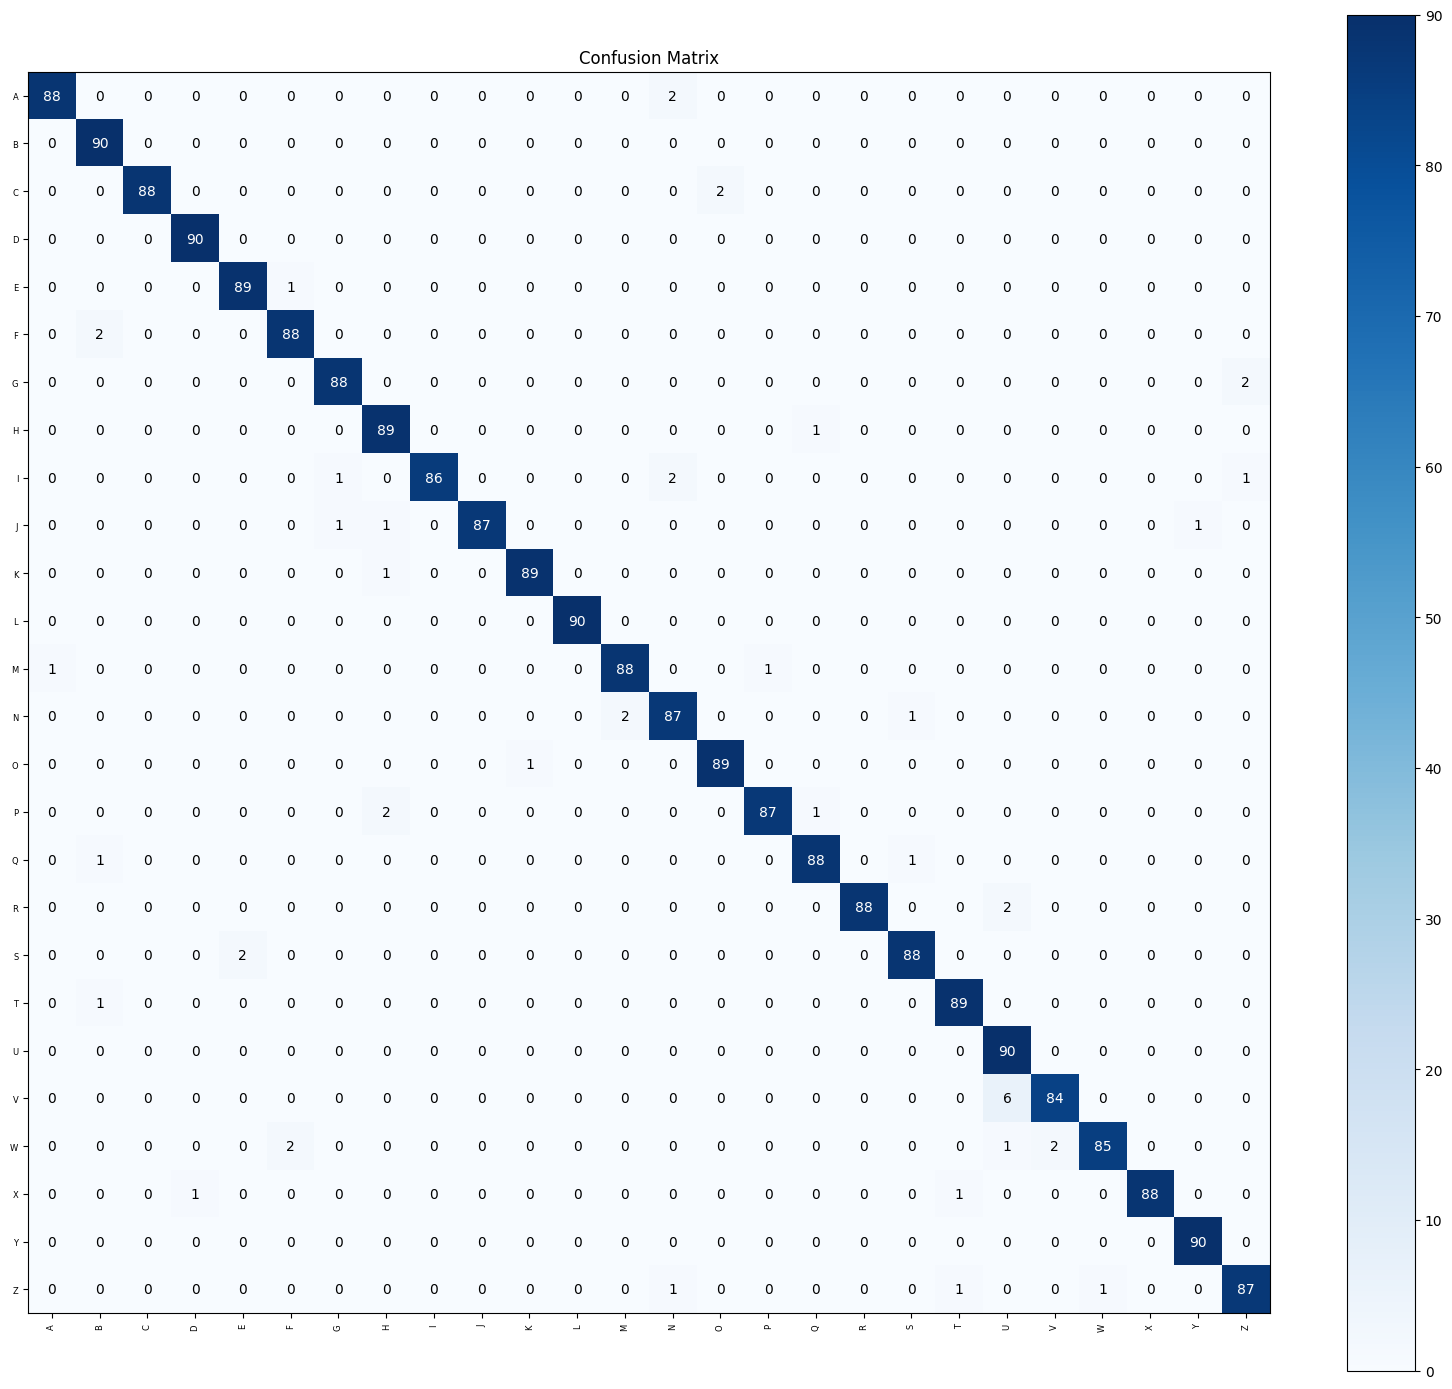

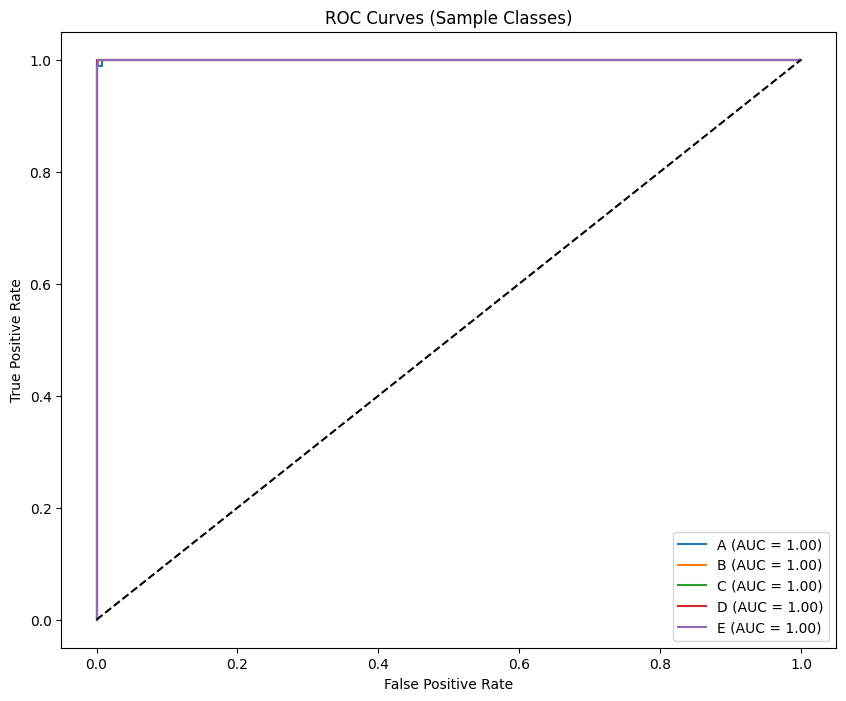

In [12]:
visualize_model(model_baseline)

Loading and processing 2340 validation images...
Loading model and predicting...
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

Results:
Accuracy: 0.9919
F1 Score: 0.9918

=== Classification Report ===
              Precision  Recall  F1-Score  Support
A                  0.98    0.99      0.98     90.0
B                  1.00    1.00      1.00     90.0
C                  0.99    1.00      0.99     90.0
D                  0.96    1.00      0.98     90.0
E                  0.98    1.00      0.99     90.0
F                  1.00    0.98      0.99     90.0
G                  0.99    1.00      0.99     90.0
H                  1.00    1.00      1.00     90.0
I                  1.00    1.00      1.00     90.0
J                  1.00    0.99      0.99     90.0
K                  1.00    1.00      1.00     90.0
L                  1.00    1.00      1.00     90.0
M                  1.00    0.99      0.99     90.0
N                  0.99    1.00      0.99     90.0
O                  0.98    1.00      0.

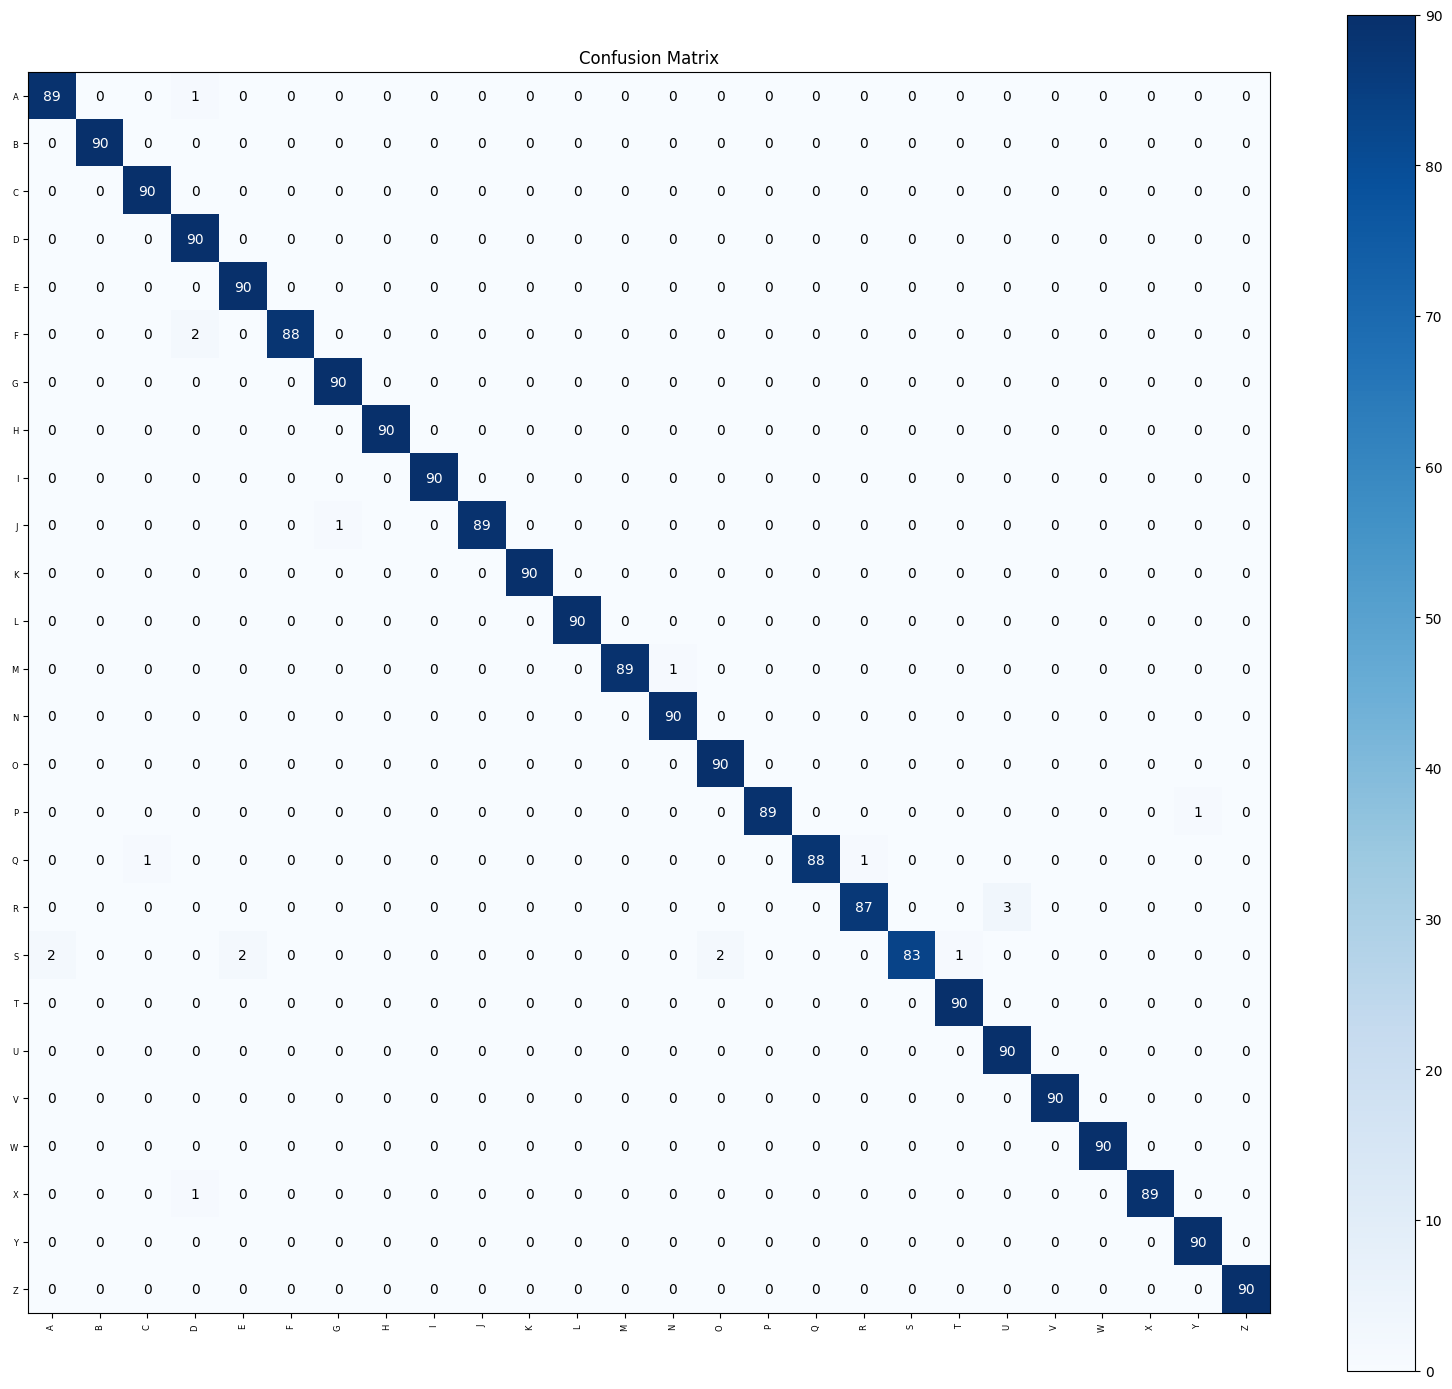

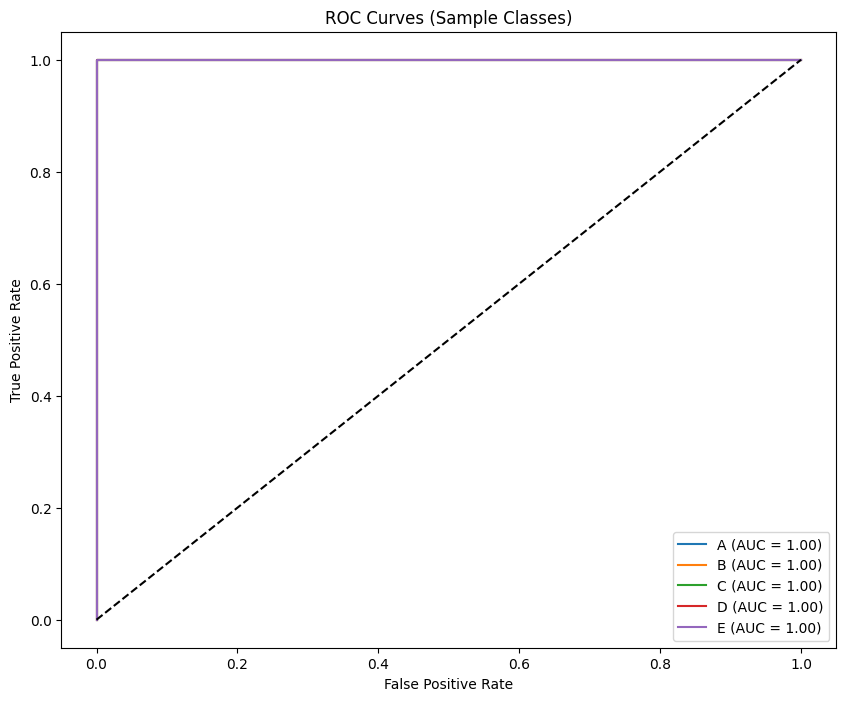

In [13]:
visualize_model(model_hypertuned)

Loading and processing 2340 validation images...
Loading model and predicting...
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 251ms/step

Results:
Accuracy: 0.9974
F1 Score: 0.9974

=== Classification Report ===
              Precision  Recall  F1-Score  Support
A                  1.00    1.00      1.00     90.0
B                  1.00    1.00      1.00     90.0
C                  1.00    1.00      1.00     90.0
D                  1.00    1.00      1.00     90.0
E                  1.00    1.00      1.00     90.0
F                  1.00    1.00      1.00     90.0
G                  1.00    1.00      1.00     90.0
H                  1.00    1.00      1.00     90.0
I                  1.00    1.00      1.00     90.0
J                  0.99    1.00      0.99     90.0
K                  1.00    1.00      1.00     90.0
L                  1.00    1.00      1.00     90.0
M                  0.99    0.98      0.98     90.0
N                  0.98    0.99      0.98     90.0
O                  1.00    1.00      

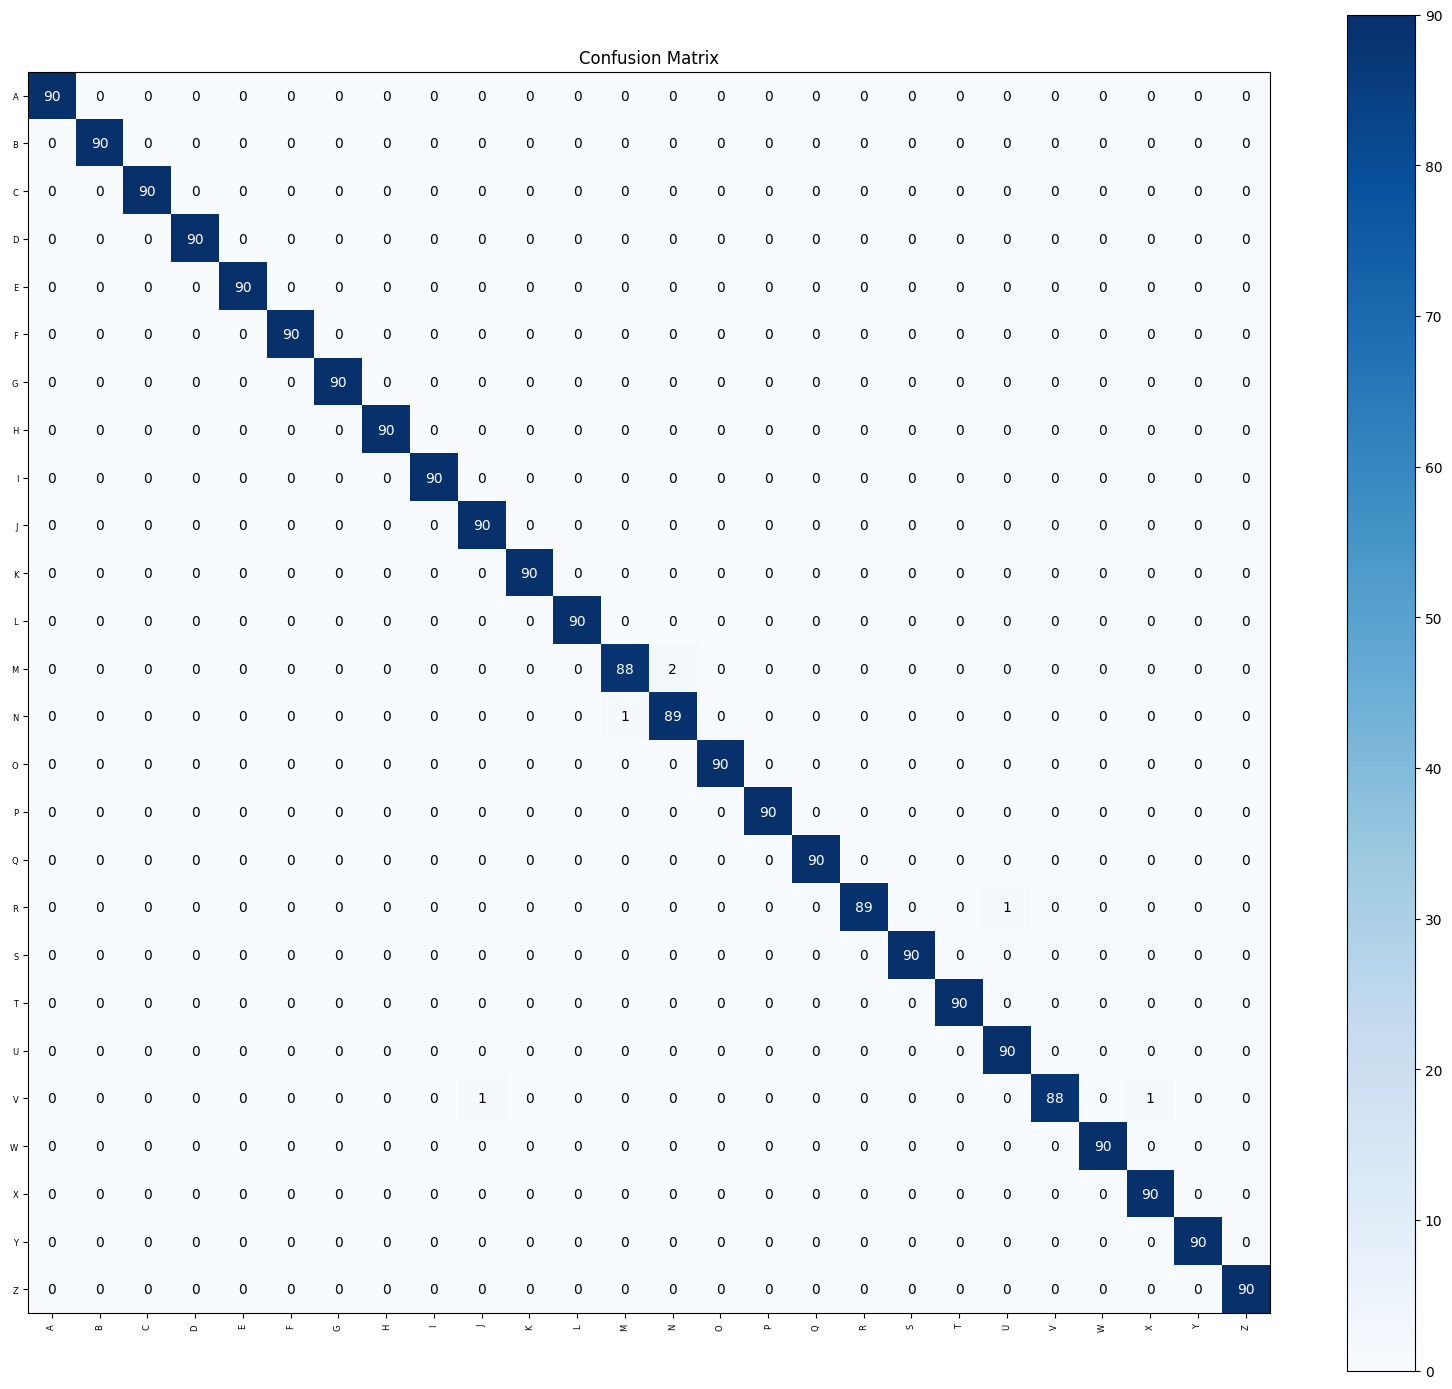

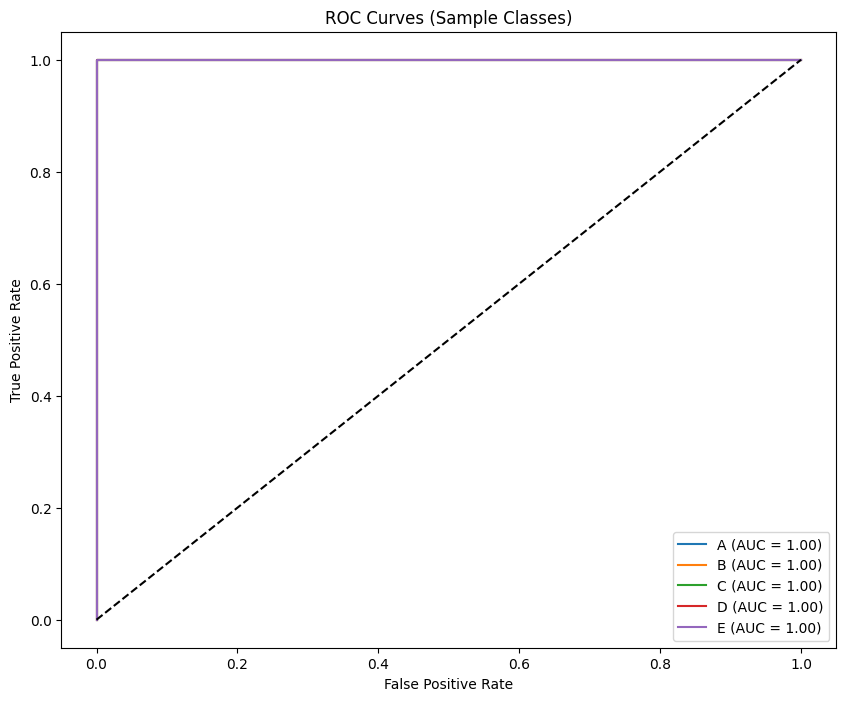

In [14]:
visualize_model(model_mobilenet)

Model Architecture Visualization

In [15]:
!git clone https://github.com/HarisIqbal88/PlotNeuralNet.git
!apt-get update -qq
!apt-get install texlive-latex-extra texlive-fonts-recommended texlive-pictures -y -qq
%cd /content/PlotNeuralNet

fatal: destination path 'PlotNeuralNet' already exists and is not an empty directory.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/content/PlotNeuralNet


In [45]:
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 39 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (323 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 155566 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


Baseline

In [78]:
%%writefile fsl_baseline.py
import sys
sys.path.append('./')

from pycore.tikzeng import *
from pycore.blocks import *

num_classes = 26

arch = [
    to_head('.'),
    to_cor(),
    to_begin(),

    # Input
    to_Conv("input", 128, 3, offset="(0,0,0)", to="(0,0,0)",
            width=2, height=40, depth=40, caption="Input\n128x128x3"),

    # Conv1
    to_Conv("conv1", 128, 32, offset="(1,0,0)", to="(input-east)",
            width=6, height=38, depth=38, caption="Conv32"),
    to_Pool("pool1", offset="(1,0,0)", to="(conv1-east)",
            width=1, height=30, depth=30),

    # Conv2
    to_Conv("conv2", 64, 64, offset="(1,0,0)", to="(pool1-east)",
            width=6, height=28, depth=28, caption="Conv64"),
    to_Pool("pool2", offset="(1,0,0)", to="(conv2-east)",
            width=1, height=22, depth=22),

    # Flatten Layer
    to_SoftMax("flatten", 128 * 128 * 3, offset="(1,0,0)", to="(pool2-east)", # Placeholder for flattened size
               width=2, height=2, depth=2, caption="Flatten"),

    # Dense
    to_SoftMax("fc1", 128, offset="(2,0,0)", to="(flatten-east)",
               width=2, height=8, depth=2, caption="Dense128"),

    # Output
    to_SoftMax("out", num_classes, offset="(2,0,0)", to="(fc1-east)",
               width=2, height=6, depth=2, caption="Softmax"),

    # Connections
    to_connection("input","conv1"),
    to_connection("conv1","pool1"),
    to_connection("pool1","conv2"),
    to_connection("conv2","pool2"),
    to_connection("pool2","flatten"),
    to_connection("flatten","fc1"),
    to_connection("fc1","out"),

    to_end()
]

def main():
    to_generate(arch, "fsl_baseline.tex")

if __name__ == '__main__':
    main()


Overwriting fsl_baseline.py


In [79]:
# Generate
!python fsl_baseline.py


\documentclass[border=8pt, multi, tikz]{standalone} 
\usepackage{import}
\subimport{./layers/}{init}
\usetikzlibrary{positioning}
\usetikzlibrary{3d} %for including external image 


\def\ConvColor{rgb:yellow,5;red,2.5;white,5}
\def\ConvReluColor{rgb:yellow,5;red,5;white,5}
\def\PoolColor{rgb:red,1;black,0.3}
\def\UnpoolColor{rgb:blue,2;green,1;black,0.3}
\def\FcColor{rgb:blue,5;red,2.5;white,5}
\def\FcReluColor{rgb:blue,5;red,5;white,4}
\def\SoftmaxColor{rgb:magenta,5;black,7}   
\def\SumColor{rgb:blue,5;green,15}


\newcommand{\copymidarrow}{\tikz \draw[-Stealth,line width=0.8mm,draw={rgb:blue,4;red,1;green,1;black,3}] (-0.3,0) -- ++(0.3,0);}

\begin{document}
\begin{tikzpicture}
\tikzstyle{connection}=[ultra thick,every node/.style={sloped,allow upside down},draw=\edgecolor,opacity=0.7]
\tikzstyle{copyconnection}=[ultra thick,every node/.style={sloped,allow upside down},draw={rgb:blue,4;red,1;green,1;black,3},opacity=0.7]


\pic[shift={(0,0,0)}] at (0,0,0) 
    {Box={
        name=

In [81]:
!pdflatex fsl_baseline.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./fsl_baseline.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/standalone/standalone.cls
Document Class: standalone 2018/03/26 v1.3a Class to compile TeX sub-files stan
dalone
(/usr/share/texlive/texmf-dist/tex/latex/tools/shellesc.sty)
(/usr/share/texlive/texmf-dist/tex/generic/iftex/ifluatex.sty
(/usr/share/texlive/texmf-dist/tex/generic/iftex/iftex.sty))
(/usr/share/texlive/texmf-dist/tex/latex/xkeyval/xkeyval.sty
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/xkeyval.tex
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/xkvutils.tex
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/keyval.tex))))
(/usr/share/texlive/texmf-dist/tex/latex/standalone/standalone.cfg)
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1

In [82]:
# Convert to PNG
!pdftoppm fsl_baseline.pdf baseline -png

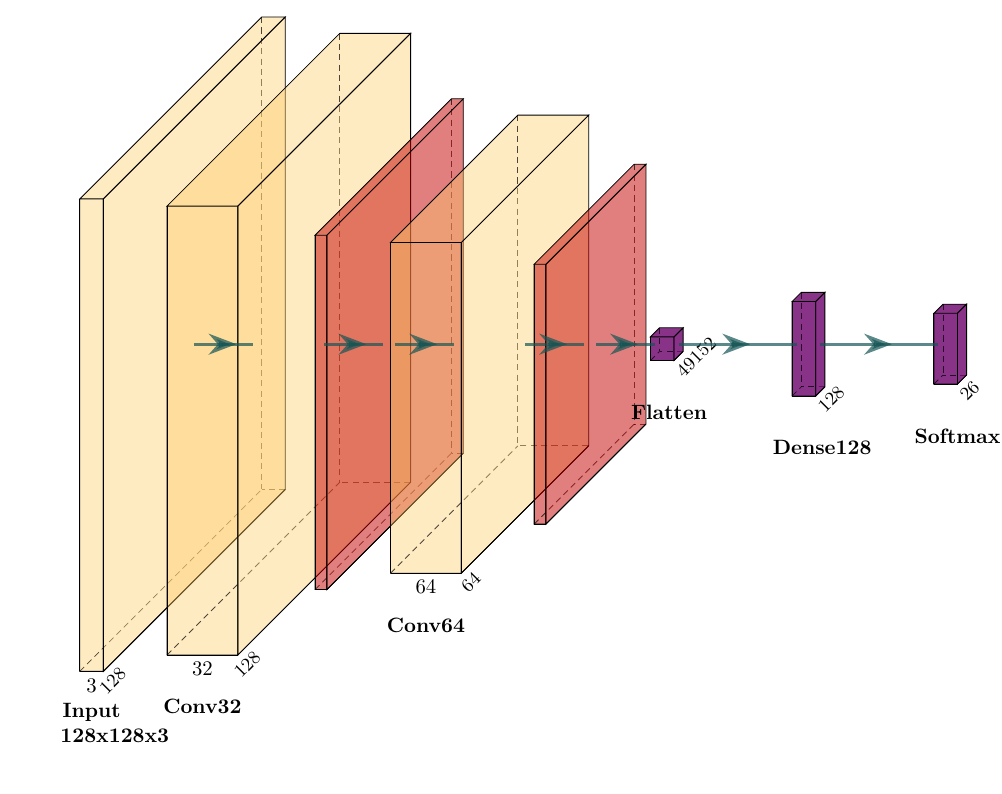

In [83]:
from IPython.display import Image, display
display(Image("baseline-1.png"))

Hypertuned

In [75]:
%%writefile hypertuned.py
import sys
sys.path.append('./')

from pycore.tikzeng import *
from pycore.blocks import *

num_classes = 26

arch = [
    to_head('.'),
    to_cor(),
    to_begin(),

    # Input: (64,64,3)
    to_Conv("input", 64, 3, offset="(0,0,0)", to="(0,0,0)",
            width=2, height=28, depth=28, caption="Input\n64x64x3"),

    # Conv1: (32,32,16)
    to_Conv("conv1", 32, 16, offset="(1,0,0)", to="(input-east)",
            width=3, height=26, depth=26, caption="Conv16"),
    to_Pool("pool1", offset="(1,0,0)", to="(conv1-east)",
            width=1, height=13, depth=13),

    # Conv2: (16,16,32)
    to_Conv("conv2", 16, 32, offset="(1,0,0)", to="(pool1-east)",
            width=4, height=13, depth=13, caption="Conv32"),
    to_Pool("pool2", offset="(1,0,0)", to="(conv2-east)",
            width=1, height=7, depth=7),

    # Flatten Layer: Output (8192) features
    to_SoftMax("flatten", 8192, offset="(1,0,0)", to="(pool2-east)",
               width=2, height=2, depth=2, caption="Flatten"),

    # Dense: Output (64) features
    to_SoftMax("fc1", 64, offset="(1,0,0)", to="(flatten-east)",
               width=2, height=6, depth=6, caption="Dense64"),

    # Output: (26) classes
    to_SoftMax("out", num_classes, offset="(2,0,0)", to="(fc1-east)",
               width=2, height=4, depth=4, caption="Softmax"),

    # Connections
    to_connection("input","conv1"),
    to_connection("conv1","pool1"),
    to_connection("pool1","conv2"),
    to_connection("conv2","pool2"),
    to_connection("pool2","flatten"),
    to_connection("flatten","fc1"),
    to_connection("fc1","out"),

    to_end()
]

def main():
    to_generate(arch, "hypertuned.tex")

if __name__ == '__main__':
    main()

Overwriting hypertuned.py


In [76]:
!python hypertuned.py


\documentclass[border=8pt, multi, tikz]{standalone} 
\usepackage{import}
\subimport{./layers/}{init}
\usetikzlibrary{positioning}
\usetikzlibrary{3d} %for including external image 


\def\ConvColor{rgb:yellow,5;red,2.5;white,5}
\def\ConvReluColor{rgb:yellow,5;red,5;white,5}
\def\PoolColor{rgb:red,1;black,0.3}
\def\UnpoolColor{rgb:blue,2;green,1;black,0.3}
\def\FcColor{rgb:blue,5;red,2.5;white,5}
\def\FcReluColor{rgb:blue,5;red,5;white,4}
\def\SoftmaxColor{rgb:magenta,5;black,7}   
\def\SumColor{rgb:blue,5;green,15}


\newcommand{\copymidarrow}{\tikz \draw[-Stealth,line width=0.8mm,draw={rgb:blue,4;red,1;green,1;black,3}] (-0.3,0) -- ++(0.3,0);}

\begin{document}
\begin{tikzpicture}
\tikzstyle{connection}=[ultra thick,every node/.style={sloped,allow upside down},draw=\edgecolor,opacity=0.7]
\tikzstyle{copyconnection}=[ultra thick,every node/.style={sloped,allow upside down},draw={rgb:blue,4;red,1;green,1;black,3},opacity=0.7]


\pic[shift={(0,0,0)}] at (0,0,0) 
    {Box={
        name=

In [77]:
!pdflatex hypertuned.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./hypertuned.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/standalone/standalone.cls
Document Class: standalone 2018/03/26 v1.3a Class to compile TeX sub-files stan
dalone
(/usr/share/texlive/texmf-dist/tex/latex/tools/shellesc.sty)
(/usr/share/texlive/texmf-dist/tex/generic/iftex/ifluatex.sty
(/usr/share/texlive/texmf-dist/tex/generic/iftex/iftex.sty))
(/usr/share/texlive/texmf-dist/tex/latex/xkeyval/xkeyval.sty
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/xkeyval.tex
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/xkvutils.tex
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/keyval.tex))))
(/usr/share/texlive/texmf-dist/tex/latex/standalone/standalone.cfg)
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4

In [73]:
!pdftoppm hypertuned.pdf hypertuned -png

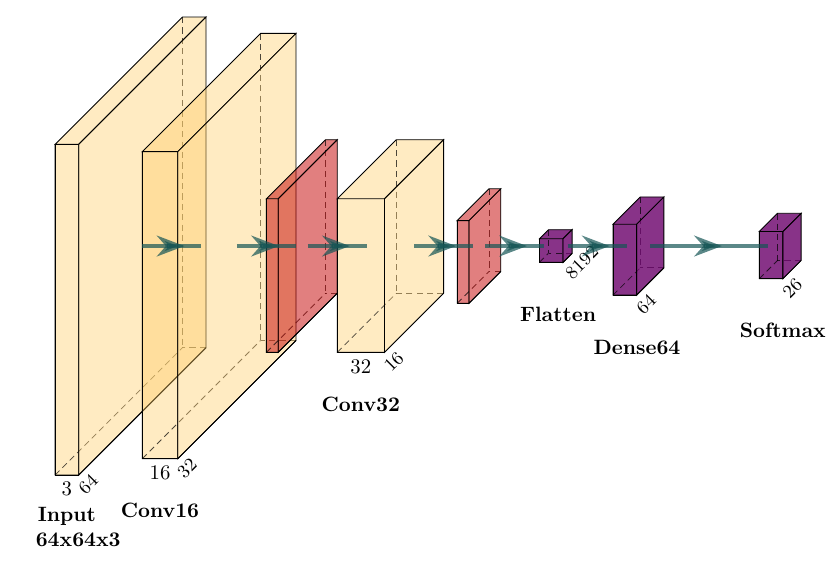

In [74]:
display(Image("hypertuned-1.png"))

Mobilenet

In [58]:
%%writefile mobilenet.py
import sys
sys.path.append('./')

from pycore.tikzeng import *
from pycore.blocks import *

num_classes = 26

arch = [
    to_head('.'),
    to_cor(),
    to_begin(),

    # Input
    to_Conv("input", 3, offset="(0,0,0)", to="(0,0,0)",
            width=2, height=32, depth=32, caption="Input\n128x128x3"),

    # MobileNet Block
    to_Conv("mobilenet", 1280, offset="(2,0,0)", to="(input-east)",
            width=6, height=28, depth=28, caption="MobileNetV2\nFeature Extractor"),

    # Global Avg Pool
    to_Pool("gap", offset="(2,0,0)", to="(mobilenet-east)",
            width=1, height=6, depth=6, caption="GAP"),

    # Dense
    to_SoftMax("fc1", 128, offset="(2,0,0)", to="(gap-east)",
               width=2, height=6, depth=6, caption="Dense128"),

    # Output
    to_SoftMax("out", num_classes, offset="(2,0,0)", to="(fc1-east)",
               width=2, height=4, depth=4, caption="Softmax"),

    # Connections
    to_connection("input","mobilenet"),
    to_connection("mobilenet","gap"),
    to_connection("gap","fc1"),
    to_connection("fc1","out"),

    to_end()
]

def main():
    to_generate(arch, "mobilenet.tex")

if __name__ == '__main__':
    main()

Overwriting mobilenet.py


In [59]:
!python mobilenet.py


\documentclass[border=8pt, multi, tikz]{standalone} 
\usepackage{import}
\subimport{./layers/}{init}
\usetikzlibrary{positioning}
\usetikzlibrary{3d} %for including external image 


\def\ConvColor{rgb:yellow,5;red,2.5;white,5}
\def\ConvReluColor{rgb:yellow,5;red,5;white,5}
\def\PoolColor{rgb:red,1;black,0.3}
\def\UnpoolColor{rgb:blue,2;green,1;black,0.3}
\def\FcColor{rgb:blue,5;red,2.5;white,5}
\def\FcReluColor{rgb:blue,5;red,5;white,4}
\def\SoftmaxColor{rgb:magenta,5;black,7}   
\def\SumColor{rgb:blue,5;green,15}


\newcommand{\copymidarrow}{\tikz \draw[-Stealth,line width=0.8mm,draw={rgb:blue,4;red,1;green,1;black,3}] (-0.3,0) -- ++(0.3,0);}

\begin{document}
\begin{tikzpicture}
\tikzstyle{connection}=[ultra thick,every node/.style={sloped,allow upside down},draw=\edgecolor,opacity=0.7]
\tikzstyle{copyconnection}=[ultra thick,every node/.style={sloped,allow upside down},draw={rgb:blue,4;red,1;green,1;black,3},opacity=0.7]


\pic[shift={(0,0,0)}] at (0,0,0) 
    {Box={
        name=

In [60]:
!pdflatex mobilenet.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./mobilenet.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/standalone/standalone.cls
Document Class: standalone 2018/03/26 v1.3a Class to compile TeX sub-files stan
dalone
(/usr/share/texlive/texmf-dist/tex/latex/tools/shellesc.sty)
(/usr/share/texlive/texmf-dist/tex/generic/iftex/ifluatex.sty
(/usr/share/texlive/texmf-dist/tex/generic/iftex/iftex.sty))
(/usr/share/texlive/texmf-dist/tex/latex/xkeyval/xkeyval.sty
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/xkeyval.tex
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/xkvutils.tex
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/keyval.tex))))
(/usr/share/texlive/texmf-dist/tex/latex/standalone/standalone.cfg)
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n

In [61]:
!pdftoppm mobilenet.pdf mobilenet -png

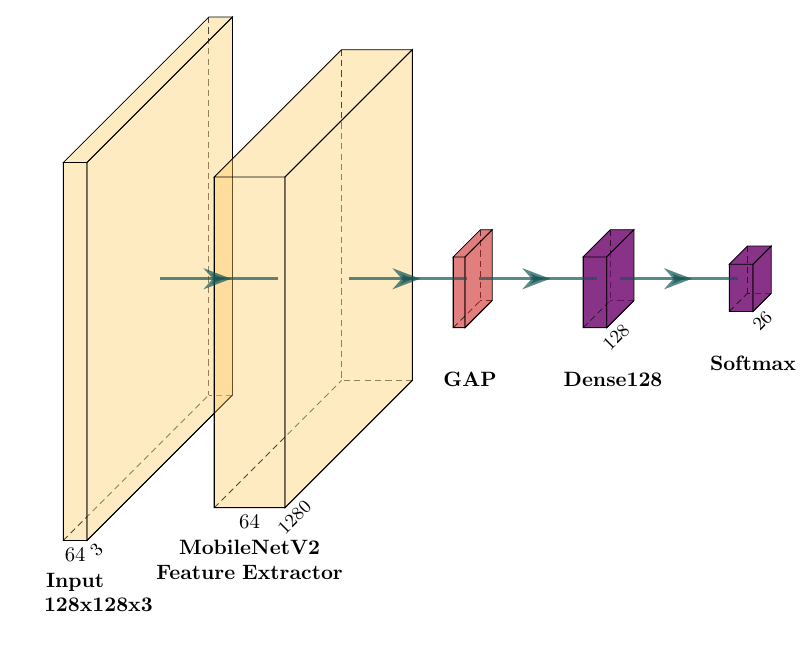

In [62]:
display(Image("mobilenet-1.png"))